## Finetuned Model Post-Processing: Optuna & 4-Fold CV

**Heads**

Default: your custom head (for the dataset you gave `--train-file` earlier)

pt_head: pre-training/replay head, samples drawn from the replay .xyz file, a snapshot of the original foundation model's training set

Get current log of Optuna trial results and place in `cv-optuna/results` (run in CLI at repo root):

`scp <LONI-source-directory>/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log` \
`scp loni:/home/zschwab/mace-finetune/cv-optuna/optuna_study.log mace-mh-1/cv-optuna/cv-results/optuna_study.log`

Get training run .out logs to fetch error metrics by running `python build_job_ids.py` in LONI (FIX)

`scp loni:/home/zschwab/mace-finetune/cv-optuna/job_ids.json mace-mh-1/cv-optuna/cv-results/job_ids.json`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import ast

# adjust to your paths
CV_ROOT = "/Users/zschwab/vscode/montemore-research/finetuned-mlips/mace-mh-1/cv-optuna/cv-results/"
STORAGE_PATH = f"{CV_ROOT}/optuna_study.log"
JOB_IDS_PATH = f"{CV_ROOT}/job_ids.json"  # from build_job_map.py
LOGS_DIR = Path(f"{CV_ROOT}/logs")

plt.rcParams["figure.dpi"] = 110

/Users/zschwab/miniconda3/envs/mace-mh-1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
storage = optuna.storages.JournalStorage(
    optuna.storages.JournalFileStorage(STORAGE_PATH)
)
summaries = optuna.study.get_all_study_summaries(storage=storage)
assert len(summaries) == 1, f"expected 1 study, found: {[s.study_name for s in summaries]}"
study_name = summaries[0].study_name
study = optuna.load_study(study_name=study_name, storage=storage)

df = study.trials_dataframe()
df = df[df["state"] == "COMPLETE"].copy()

# expand fold-level lists (stored as strings by trials_dataframe -> literal_eval)
df["fold_rmse_e"] = df["user_attrs_fold_rmse_e"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df["fold_rmse_f"] = df["user_attrs_fold_rmse_f"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df.sort_values("value")

/var/folders/nq/bjj6kssx74500m34s24x3mf00000gn/T/ipykernel_62119/1486352069.py:2: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  optuna.storages.JournalFileStorage(STORAGE_PATH)


,number,value,datetime_start,datetime_complete,duration,params_lr,params_swa_energy_weight,params_swa_forces_weight,params_swa_lr,params_weight_decay,user_attrs_fold_rmse_e,user_attrs_fold_rmse_f,user_attrs_fold_std,state,fold_rmse_e,fold_rmse_f
10,10,25.168250,2026-07-29 14:05:54.214778,2026-07-29 16:01:28.294697,0 days 01:55:34.079919,0.000470,8.229810,60.146578,0.000096,5.178204e-08,"[16.45, 21.13, 16.86, 71.61]","[19.58, 20.91, 18.67, 20.75]",1.054178,COMPLETE,"[16.45, 21.13, 16.86, 71.61]","[19.58, 20.91, 18.67, 20.75]"
11,11,25.212500,2026-08-02 15:55:57.844387,2026-08-02 17:54:02.651156,0 days 01:58:04.806769,0.000483,8.540890,52.850636,0.000098,5.576727e-08,"[16.28, 21.28, 16.66, 71.6]","[19.75, 21.05, 18.68, 20.94]",1.117572,COMPLETE,"[16.28, 21.28, 16.66, 71.6]","[19.75, 21.05, 18.68, 20.94]"
13,13,25.234250,2026-08-02 19:50:05.789610,2026-08-02 21:45:38.649416,0 days 01:55:32.859806,0.000495,7.693208,50.515940,0.000097,5.139791e-08,"[16.62, 21.37, 17.08, 70.98]","[19.73, 21.07, 18.7, 20.89]",1.104819,COMPLETE,"[16.62, 21.37, 17.08, 70.98]","[19.73, 21.07, 18.7, 20.89]"
9,9,25.301875,2026-07-29 12:09:49.242837,2026-07-29 14:05:54.140515,0 days 01:56:04.897678,0.000027,5.435109,111.289453,0.000094,2.012310e-08,"[18.67, 21.53, 20.15, 69.21]","[19.22, 20.43, 18.18, 20.18]",1.024382,COMPLETE,"[18.67, 21.53, 20.15, 69.21]","[19.22, 20.43, 18.18, 20.18]"
7,7,25.317125,2026-07-29 08:17:42.441394,2026-07-29 10:14:15.942994,0 days 01:56:33.501600,0.000034,9.469520,100.183668,0.000061,1.414847e-08,"[17.85, 21.5, 18.87, 69.52]","[19.55, 20.87, 18.58, 20.61]",1.050377,COMPLETE,"[17.85, 21.5, 18.87, 69.52]","[19.55, 20.87, 18.58, 20.61]"
15,15,25.735500,2026-08-02 23:41:11.511455,2026-08-03 01:36:44.378363,0 days 01:55:32.866908,0.000271,7.816133,68.008534,0.000053,1.652221e-07,"[19.14, 22.12, 20.16, 68.56]","[19.81, 21.11, 18.93, 20.97]",1.030518,COMPLETE,"[19.14, 22.12, 20.16, 68.56]","[19.81, 21.11, 18.93, 20.97]"
18,18,25.759000,2026-08-03 05:28:20.002614,2026-08-03 07:23:22.868366,0 days 01:55:02.865752,0.000343,8.662289,59.054135,0.000049,1.000919e-09,"[19.01, 22.02, 19.99, 68.57]","[19.95, 21.25, 18.99, 21.12]",1.066220,COMPLETE,"[19.01, 22.02, 19.99, 68.57]","[19.95, 21.25, 18.99, 21.12]"
19,19,25.896250,2026-08-03 07:23:22.873045,2026-08-03 09:19:55.773712,0 days 01:56:32.900667,0.000208,3.451242,80.084374,0.000068,2.157429e-07,"[20.68, 23.08, 22.55, 66.48]","[19.57, 20.87, 18.57, 20.68]",1.068500,COMPLETE,"[20.68, 23.08, 22.55, 66.48]","[19.57, 20.87, 18.57, 20.68]"
12,12,26.048000,2026-08-02 17:54:02.727576,2026-08-02 19:50:05.786326,0 days 01:56:03.058750,0.000442,9.333688,50.797039,0.000035,5.561700e-08,"[19.87, 22.64, 21.26, 67.68]","[20.04, 21.4, 19.14, 21.31]",1.083863,COMPLETE,"[19.87, 22.64, 21.26, 67.68]","[20.04, 21.4, 19.14, 21.31]"
4,4,26.320125,2026-07-29 02:29:31.829388,2026-07-29 04:25:34.822656,0 days 01:56:02.993268,0.000120,6.304723,122.244338,0.000028,1.961512e-07,"[21.5, 23.71, 23.84, 65.98]","[19.89, 21.19, 18.88, 20.98]",1.068036,COMPLETE,"[21.5, 23.71, 23.84, 65.98]","[19.89, 21.19, 18.88, 20.98]"


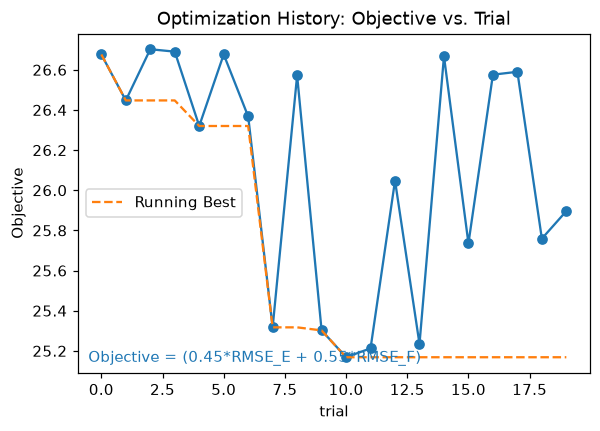

Objective: composite score (meV/atom + meV/Å, weighted)


In [3]:
# 1a. optimization history
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(df["number"], df["value"], "o-")
running_best = df.sort_values("number")["value"].cummin()
ax.plot(df.sort_values("number")["number"], running_best, "--", label="Running Best")
ax.set_xlabel("trial")
ax.set_ylabel("Objective")
ax.set_title("Optimization History: Objective vs. Trial")
ax.text(0.02, 0.02, 
        "Objective = (0.45*RMSE_E + 0.55*RMSE_F)", 
        transform=ax.transAxes, ha="left", va="bottom",
        color="tab:blue")
ax.legend()
plt.show()

print("Objective: composite score (meV/atom + meV/Å, weighted)")

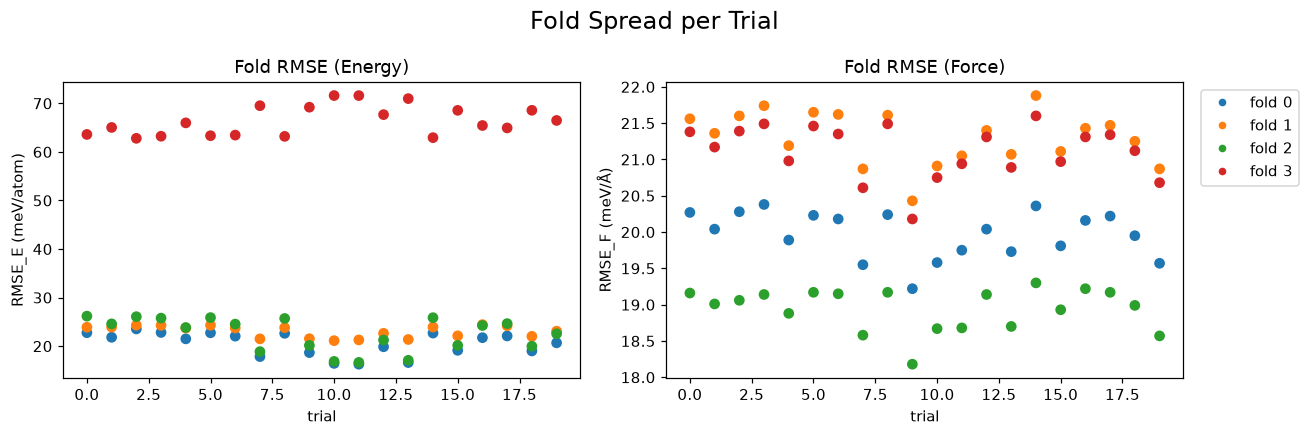

In [4]:
# 1c. fold spread per trial — the important one (fold-3 outlier check)
n_folds = len(df["fold_rmse_e"].iloc[0])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for metric_idx, (metric_name, ax) in enumerate(zip(["fold_rmse_e", "fold_rmse_f"], axes)):
    for _, row in df.sort_values("number").iterrows():
        vals = row[metric_name]
        xs = [row["number"]] * n_folds
        ax.scatter(xs, vals, c=range(n_folds), cmap="tab10", vmin=0, vmax=9)
    ax.set_xlabel("trial")
    y_name = "RMSE_E (meV/atom)" if metric_name == "fold_rmse_e" else "RMSE_F (meV/Å)"
    ax.set_ylabel(y_name)
    title_name = "Fold RMSE (Energy)" if metric_name == "fold_rmse_e" else "Fold RMSE (Force)"
    ax.set_title(title_name)

# legend for fold colors
handles = [plt.Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=plt.cm.tab10(i / 9), label=f"fold {i}")
            for i in range(n_folds)]
axes[1].legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Fold Spread per Trial", fontsize=16)
fig.tight_layout()
plt.show()

In [5]:
importances = optuna.importance.get_param_importances(study)
for param, imp in importances.items():
    print(f"{param:20s} {imp:.3f}")

swa_lr               0.948
weight_decay         0.022
lr                   0.012
swa_forces_weight    0.010
swa_energy_weight    0.009


# Final Training Run
#### Use hyperparameters from the lowest-error Optuna trial in the study and train on the entire test set (all 4 folds).

In [8]:
best_row = df.loc[df["value"].idxmin()]
rmse_f = best_row["fold_rmse_f"]
rmse_e = best_row["fold_rmse_e"]

print(f"""best trial: #{int(best_row['number'])}
params: {study.best_params}

fold RMSE_F (meV/A):      {rmse_f}      mean RMSE_F: {np.mean(rmse_f):.3f}
fold RMSE_E (meV/atom):   {rmse_e}      mean RMSE_E: {np.mean(rmse_e):.3f}

final optimized value (0.45*RMSE_E + 0.55*RMSE_F): {best_row['value']:.4f}""")

best trial: #10
params: {'lr': 0.00047031542728235995, 'weight_decay': 5.178204195538144e-08, 'swa_lr': 9.556831837908884e-05, 'swa_energy_weight': 8.229809512646524, 'swa_forces_weight': 60.146577956482155}

fold RMSE_F (meV/A):      [19.58, 20.91, 18.67, 20.75]      mean RMSE_F: 19.977
fold RMSE_E (meV/atom):   [16.45, 21.13, 16.86, 71.61]      mean RMSE_E: 31.512

final optimized value (0.45*RMSE_E + 0.55*RMSE_F): 25.1683


After `scp`-ing `full_train.sh` over to your LONI directory, copy and paste the `sbatch` command printed below to run.

In [9]:
params = study.best_params

sbatch_cmd = (
    f"sbatch full_train.sh "
    f"{params['lr']} "
    f"{params['weight_decay']} "
    f"{params['swa_lr']} "
    f"{params['swa_energy_weight']} "
    f"{params['swa_forces_weight']}"
)

print(sbatch_cmd)

sbatch full_train.sh 0.00047031542728235995 5.178204195538144e-08 9.556831837908884e-05 8.229809512646524 60.146577956482155
